# AG-HYPOPT · Trial 01

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

This is trial_01 of a fresh experiment_6 campaign; trials.json starts with an empty `trials` list, so there are no previous trials and no current best to reference. The campaign searches the score design (sigma_weight, h_f_scale, h_s_scale, gamma_rel_cap) on the real 14-experiment PLE data with the experiment_5 schedule frozen, on the 8-experiment benchmark (1nW/3nW x Trans05/20/60/100), n_runs=100, n_iter=30. Objective = T-weighted mean of capped per-cell rel-sq errors (lower better); reference level is the experiment_5 honest range ~0.108-0.113 (headline 0.1074). Success needs gamma finite on all 8 cells and fewer/zero diverged cells.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_01'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = uniform  (0/5 trials)
ID |     ei | params
 1 |      - | {"gamma_rel_cap": 0.25591081235012836, "h_f_scale": 3.8142388612222575, "h_s_scale": 0.7905985476986265, "sigma_weight": 0.9486494471372439}
 2 |      - | {"gamma_rel_cap": 0.15591572600524273, "h_f_scale": 1.8374741836471586, "h_s_scale": 3.3538847268266565, "sigma_weight": 0.4091991363691613}
 3 |      - | {"gamma_rel_cap": 0.27479684383652975, "h_f_scale": 0.3533466746615064, "h_s_scale": 3.075674157530525, "sigma_weight": 0.5381433132192782}
 4 |      - | {"gamma_rel_cap": 0.16486585824954608, "h_f_scale": 3.206607637856516, "h_s_scale": 1.3869806098436688, "sigma_weight": 0.4534978894806515}
 5 |      - | {"gamma_rel_cap": 0.06702084862358237, "h_f_scale": 1.7616736991767346, "h_s_scale": 1.0129571525355612, "sigma_weight": 0.2623133404418495}
 6 |      - | {"gamma_rel_cap": 0.3751823363150263, "h_f_scale": 1.3015328424476498, "h_s_scale": 2.0694661541186314, "sigma_weight": 0.9807371998012386}
 7 |      - | {"gamma_

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

No previous trials exist (empty registry) and this is a uniform-phase batch, so every candidate carries ei = '-' and none is favoured by the optimizer; the choice rests on the candidate values and the FM#8 physics.

Candidate 2: sigma_weight 0.41 damps the sigma_fit channel moderately (the report's #1 fix direction for the spurious low-mu mode), and h_s_scale 3.35 flattens the sigma kernel so that channel is damped further in the same direction; h_f_scale 1.84 mildly loosens the FWHM kernel for the skewed target (FM#4), and gamma_rel_cap 0.156 bounds the per-step gamma move, guarding the sporadic low-count gamma blow-up without touching mu.

As the first trial this is an opening probe of the headline score-design hypothesis, and it seeds the registry for the later trials-phase proposals. I choose candidate 2.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 2               # candidate 2: sigma_weight 0.409, h_s_scale 3.354, h_f_scale 1.837, gamma_rel_cap 0.156


chosen: {'gamma_rel_cap': 0.15591572600524273, 'h_f_scale': 1.8374741836471586, 'h_s_scale': 3.3538847268266565, 'sigma_weight': 0.4091991363691613}
Running  1nW Trans05 ... 

μ 9.39 -> 8.11 | γ 8.5 -> 3.56 | NLL 0.66


Running  1nW Trans20 ... 

μ 17.32 -> 37.48 | γ 8.5 -> 6.22 | NLL 1.45


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 69.58 | γ 14.1 -> 14.27 | NLL 1.35


Running 3nW Trans100 ... 

μ 175.71 -> 100.92 | γ 14.1 -> 14.05 | NLL 1.36



Total: 7.1 min


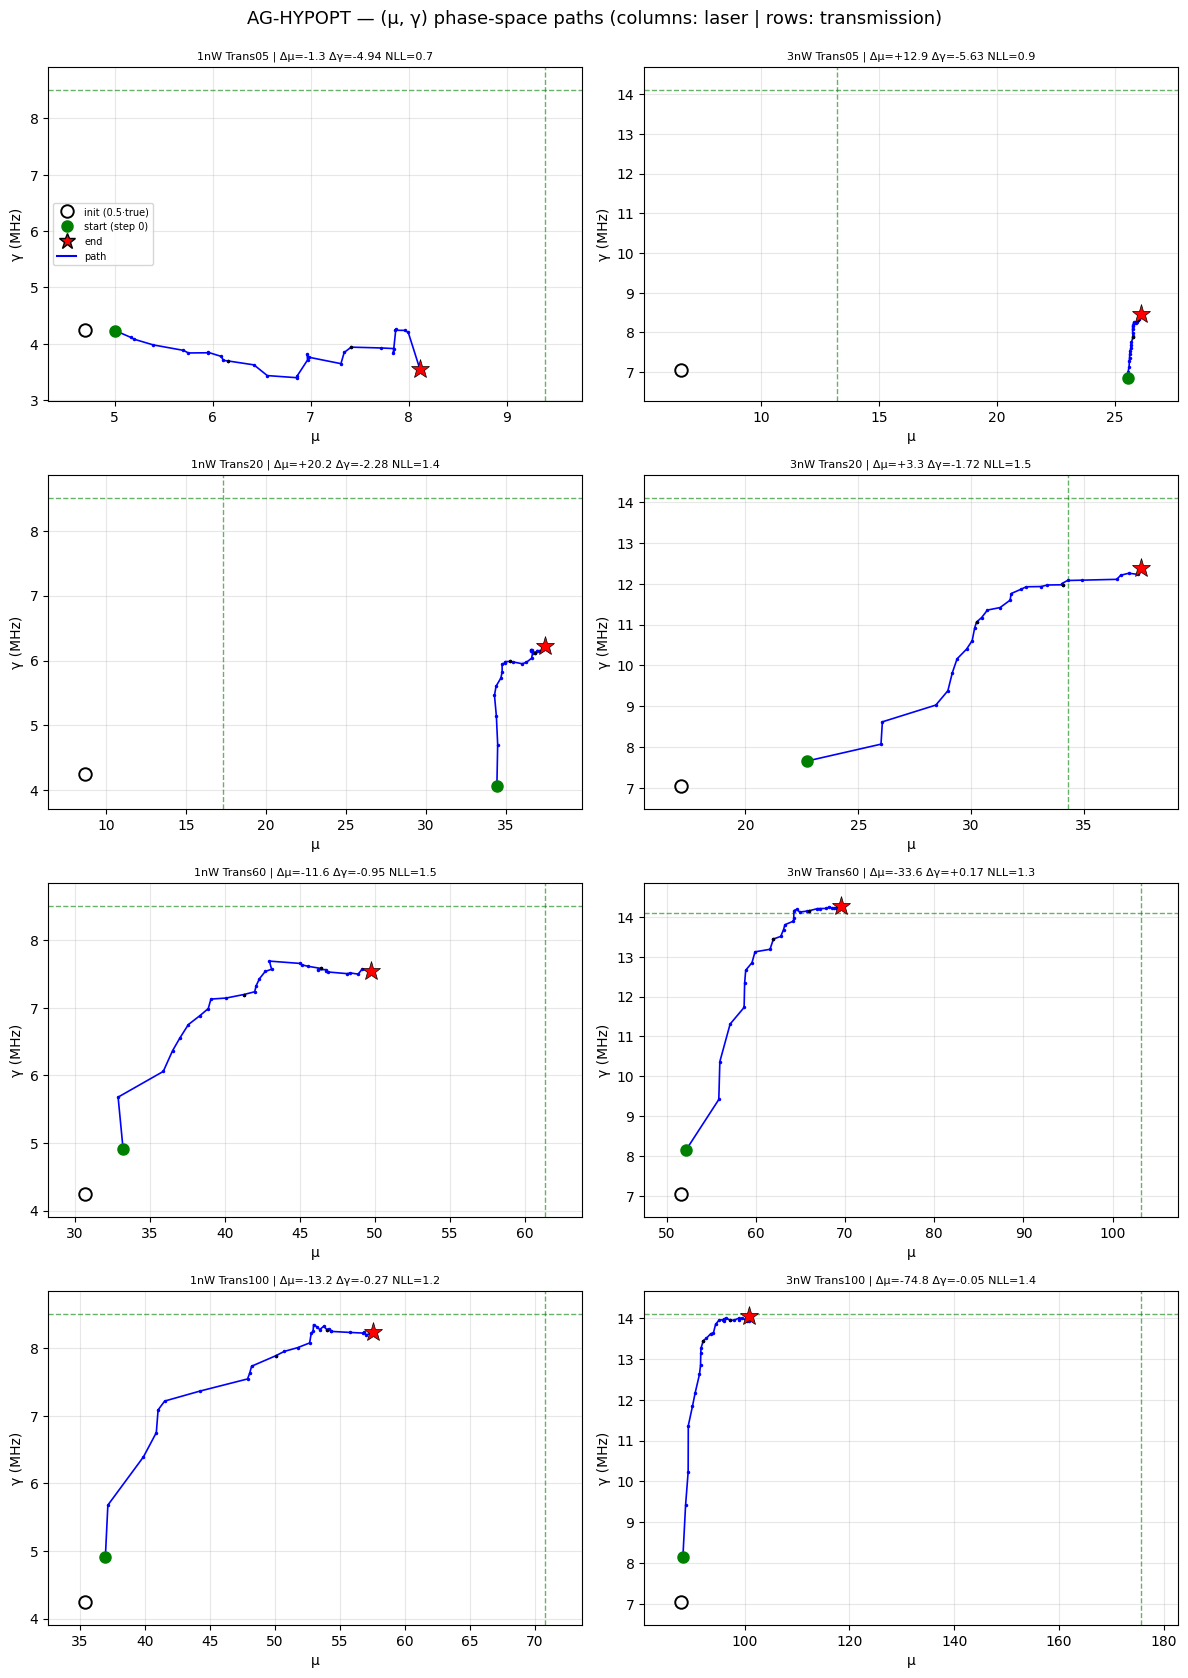

trial finished in 7.1 min
objective = 0.1243 ± 0.0809
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    8.11   -13.6 |     8.50    3.56   -58.1
1nW Trans20       17.32   37.48  +116.4 |     8.50    6.22   -26.8
1nW Trans60       61.37   49.74   -19.0 |     8.50    7.55   -11.2
1nW Trans100       70.82   57.60   -18.7 |     8.50    8.23    -3.1
3nW Trans05       13.20   26.13   +97.9 |    14.10    8.47   -39.9
3nW Trans20       34.28   37.54    +9.5 |    14.10   12.38   -12.2
3nW Trans60      103.20   69.58   -32.6 |    14.10   14.27    +1.2
3nW Trans100      175.71  100.92   -42.6 |    14.10   14.05    -0.3

weighted objective (T-graded, cap=1.0) = 0.1243 | diverged cells: 0
μ: RMSE 30.862 (rel 58.1%, bias -12.274) | γ: RMSE 2.855 (rel 27.3%, bias -1.958)


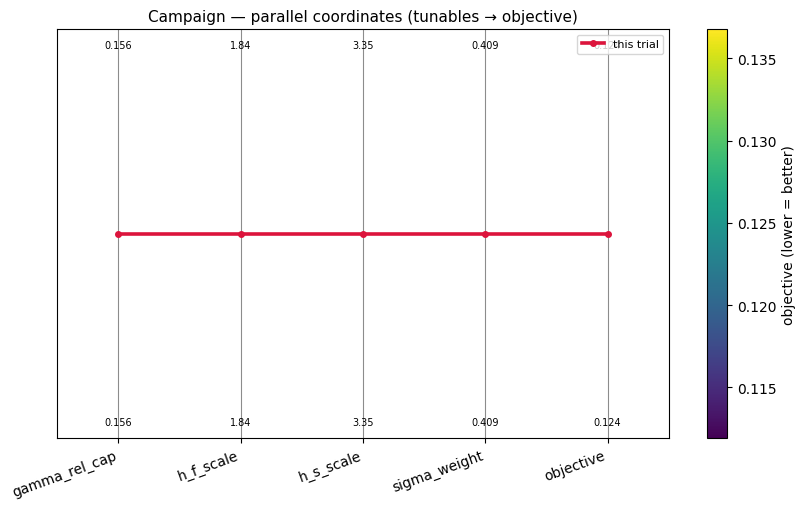

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 01 ran to completion in 7.1 min on the 8-experiment benchmark, 0 diverged cells and gamma finite on all cells (the divergence guard never fired).

Objective = 0.1243 +/- 0.0809 (T-weighted, capped), above the experiment_5 honest level (~0.108-0.113) and the 0.1074 headline.

mu was badly off and mixed in sign: +116.4% at 1nW Trans20 and +97.9% at 3nW Trans05 (overshoot to high mu at low T), while the high-T cells undershoot strongly (3nW Trans100 -42.6%, 3nW Trans60 -32.6%, 1nW Trans60 -19.0%); overall mu RMSE 30.86 (rel 58.1%, bias -12.27).

gamma was under-estimated at low T (1nW Trans05 -58.1%, 3nW Trans05 -39.9%, 1nW Trans20 -26.8%) but essentially recovered at high T (-3.1%, -0.3%, +1.2%); overall gamma RMSE 2.86 (rel 27.3%, bias -1.96).

This is the campaign's first recorded trial, so there is no earlier result to compare against; the only reference is the experiment_5 level.

**Summary:** Trial 01 (sw=0.409, h_f=1.837, h_s=3.354, cap=0.156) finished in 7.1 min with 0 diverged cells and gamma finite throughout, but objective 0.1243 +/- 0.0809 sits above the experiment_5 honest level (~0.108-0.113), driven by badly biased mu (rel-RMSE 58.1%).
**Key insight:** Moderate sigma-channel damping (sw 0.41) with a flattened sigma kernel (h_s 3.35) keeps gamma finite and divergence-free but leaves mu strongly biased, so this score design does not yet beat the frozen exp5 level.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
Notes for Anuar: none (no structural-change proposals).


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 01 (sw=0.409, h_f=1.837, h_s=3.354, cap=0.156): objective 0.1243 +/- 0.0809 above the exp5 honest level; 0 diverged cells, gamma finite on all 8 (mu rel-RMSE 58.1%, gamma rel-RMSE 27.3%).'
KEY_INSIGHT = 'Moderate sigma damping (sw 0.41) + flat sigma kernel (h_s 3.35) keeps gamma finite and divergence-free, but mu stays strongly biased, so the score design alone does not yet beat the frozen exp5 level.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_01 | current best: trial_01


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_02.ipynb. Open it and follow its cells from the top.
